
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

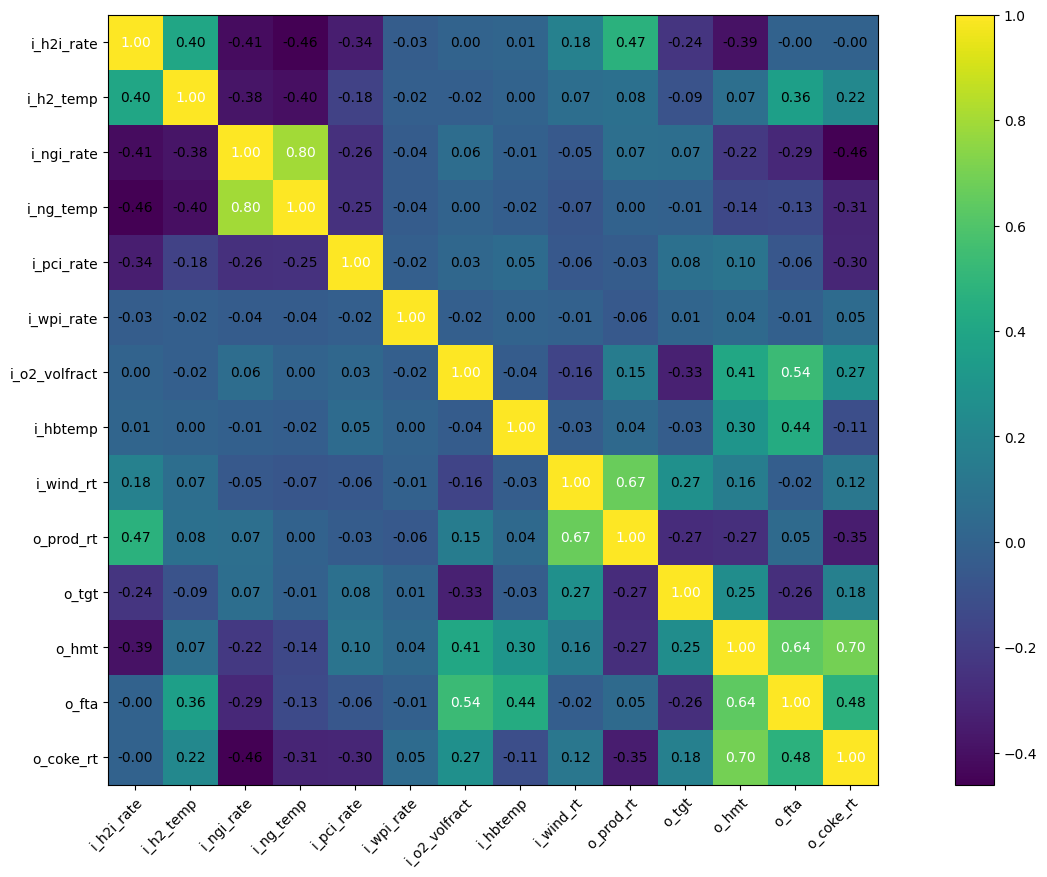

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.49452173709869385
100 ..... 0.8523623943328857
200 ..... 0.28324636816978455
300 ..... 0.14657290279865265
400 ..... 0.1381489634513855
500 ..... 0.20177391171455383
600 ..... 0.13892991840839386
700 ..... 0.11759617924690247
800 ..... 0.17467841506004333
900 ..... 0.6689174771308899


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.4813, 1298.5352, 8453.1064, 2308.0481,  417.0606]])
y_deviations: tensor([[  50.2664,  525.0270, 1507.6536,  210.3159,   50.2079]])
x_means: tensor([[  12.5306,   18.9647,   41.1788,   25.6069,  415.6789, 1440.8802,
          198.6672]])
x_deviations: tensor([[ 15.3287,  45.7489,  46.6067,   3.3204, 271.7052, 157.9338,  26.5069]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.2149,  773.5082, 6945.4531, 2097.7322,  366.8527]])
tensor([[ 147.7477, 1823.5621, 9960.7598, 2518.3640,  467.2685]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.7980,  -26.7842,   -5.4279,   22.2865,  143.9738, 1282.9464,
          172.1602]])
tensor([[  27.8593,   64.7137,   87.7855,   28.9273,  687.3841, 1598.8141,
          225.1741]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  


In [31]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_real = torch.tensor(price_real, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [32]:

lambda_cost = 0.001   ## this gave 86% percent of cases improvement
lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [33]:



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point
    
    x_temp = x_starting_point.clone().detach().requires_grad_(True)
    
    ## x_temp = torch.randn_like(x_starting_point).requires_grad_(True)

    optimizer = torch.optim.Adam([x_temp], lr=learning_rate)
    
    for j in range(1000):
        
        optimizer.zero_grad()
        
        _, current_y = model_Forward(x_temp)
        
        
        loss_main = torch.mean((current_y - target_y)**2)
        loss_cost = lambda_cost * torch.dot(price_real, x_temp)
        loss      = loss_main + loss_cost
        
        loss.backward()
        optimizer.step()
        
        
    
        #######################
        
     
        x_temp_pred_np   = x_temp.detach().numpy()
        cost_pred        = np.dot(price_real, x_temp_pred_np)
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
       
        if j % 200 == 0:           ## 20
            print(f"iteration {j} cost: {cost_pred}...H2, PCI, NGI:", x_temp_pred_np[:3] )
            print("real cost       :", cost_real)
            print( loss )
        
   
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
          
    cost_diffs.append(    cost_diff  )
      

    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np )
    print( "real" )
    print( x_real_np )
    print("...")
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np))   )
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    print(i)
    print('********************************')




iteration 0 cost: 80.05500030517578...H2, PCI, NGI: [20.01        0.00999997  0.00999997]
real cost       : 200.0
tensor(1.5933, grad_fn=<AddBackward0>)
iteration 200 cost: 89.23715209960938...H2, PCI, NGI: [21.535131   2.120699   1.9518592]
real cost       : 200.0
tensor(1.3069, grad_fn=<AddBackward0>)
iteration 400 cost: 96.121826171875...H2, PCI, NGI: [22.462301   4.3099566  3.9253237]
real cost       : 200.0
tensor(1.1264, grad_fn=<AddBackward0>)
iteration 600 cost: 103.36180114746094...H2, PCI, NGI: [23.43243    6.7170386  5.830083 ]
real cost       : 200.0
tensor(1.0032, grad_fn=<AddBackward0>)
iteration 800 cost: 110.32334899902344...H2, PCI, NGI: [24.31067    9.3101425  7.541041 ]
real cost       : 200.0
tensor(0.9131, grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  25.037228   11.904057    9.080233   30.628298  310.3065   1208.5944
  221.2843  ]
real
[  50.    0.    0.   27. 1200. 1600.  19

iteration 200 cost: 70.76241302490234...H2, PCI, NGI: [18.29536   -1.5501714 -1.7377204]
real cost       : 40.0
tensor(0.4078, grad_fn=<AddBackward0>)
iteration 400 cost: 62.26618194580078...H2, PCI, NGI: [16.605442  -2.5568326 -3.1975064]
real cost       : 40.0
tensor(0.3040, grad_fn=<AddBackward0>)
iteration 600 cost: 53.12917709350586...H2, PCI, NGI: [14.709009  -3.4423454 -4.5290265]
real cost       : 40.0
tensor(0.1933, grad_fn=<AddBackward0>)
iteration 800 cost: 48.48859405517578...H2, PCI, NGI: [13.774656 -3.935833 -5.348399]
real cost       : 40.0
tensor(0.1609, grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  12.970264    -4.3971415   -6.098762    24.604298   295.8847
 1204.276      237.63972  ]
real
[  10.    0.    0.   27.  300. 1200.  230.]
...
y pred
tensor([[ 115.8960, 1639.3392, 8850.3457, 2261.0212,  494.5423]])
y real
tensor([[ 106.2379, 1813.3184, 8727.1582, 2347.7146,  503.3678]])


iteration 200 cost: 70.51078033447266...H2, PCI, NGI: [18.082172  -0.974376  -1.6870674]
real cost       : 160.0
tensor(0.7974, grad_fn=<AddBackward0>)
iteration 400 cost: 57.836307525634766...H2, PCI, NGI: [15.28427    -0.69780594 -5.2059326 ]
real cost       : 160.0
tensor(0.6062, grad_fn=<AddBackward0>)
iteration 600 cost: 53.01030731201172...H2, PCI, NGI: [13.352629  1.279199 -3.358814]
real cost       : 160.0
tensor(0.5038, grad_fn=<AddBackward0>)
iteration 800 cost: 49.37721252441406...H2, PCI, NGI: [11.668568    3.0477283  -0.68957645]
real cost       : 160.0
tensor(0.4505, grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  10.311415     5.1477346    2.3290663   19.084045   309.73087
 1212.726      224.39525  ]
real
[  40.    0.    0.   21.  900. 1480.  195.]
...
y pred
tensor([[ 146.3443, 1068.7906, 7719.7021, 2024.3374,  451.1692]])
y real
tensor([[  92.4594,  608.6695, 8792.4365, 2221.2534,  

iteration 400 cost: 61.66900634765625...H2, PCI, NGI: [16.209457  -1.602389  -3.1328661]
real cost       : 105.0
tensor(0.2466, grad_fn=<AddBackward0>)
iteration 600 cost: 56.121089935302734...H2, PCI, NGI: [14.627929  -0.6862199 -3.408807 ]
real cost       : 105.0
tensor(0.2040, grad_fn=<AddBackward0>)
iteration 800 cost: 55.78369140625...H2, PCI, NGI: [13.887618   1.3560166 -2.245597 ]
real cost       : 105.0
tensor(0.1857, grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  13.282005     3.4647686   -0.7356223   22.942366   304.48325
 1209.5        221.94862  ]
real
[  20.    0.   50.   27.  300. 1480.  195.]
...
y pred
tensor([[ 114.2502, 1314.2671, 8303.5537, 2165.6672,  465.8219]])
y real
tensor([[  78.2979, 1115.4598, 8996.0713, 2291.5254,  410.4767]])
22
********************************
iteration 0 cost: 79.9749984741211...H2, PCI, NGI: [19.99        0.00999991  0.00999976]
real cost       : 70.

iteration 600 cost: 96.67510986328125...H2, PCI, NGI: [22.444092   4.6203027  4.5568805]
real cost       : 200.0
tensor(0.6366, grad_fn=<AddBackward0>)
iteration 800 cost: 99.80532836914062...H2, PCI, NGI: [22.652967   6.1831627  6.0205913]
real cost       : 200.0
tensor(0.6123, grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  22.757263     7.806588     7.5115094   23.86845    310.46744
 1210.8693     225.9988   ]
real
[   0.  200.    0.   30.  300. 1200.  195.]
...
y pred
tensor([[  94.8834,  924.0594, 9651.7969, 2125.6816,  432.1482]])
y real
tensor([[  86.9866, 1292.6847, 9181.8398, 2206.8972,  363.6049]])
29
********************************
iteration 0 cost: 80.05500030517578...H2, PCI, NGI: [20.01  0.01  0.01]
real cost       : 60.0
tensor(1.2576, grad_fn=<AddBackward0>)
iteration 200 cost: 89.90071868896484...H2, PCI, NGI: [21.784546   1.8575711  1.8099258]
real cost       : 60.0
tensor(0.9703,

...

iteration 800 cost: 107.15296936035156...H2, PCI, NGI: [23.989466   7.6275353  7.135139 ]
real cost       : 60.0
tensor(0.4546, grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  24.143969    9.559597    8.743264   28.517786  309.75113  1208.6777
  218.31139 ]
real
[   0.    0.  120.   30.  300. 1448.  195.]
...
y pred
tensor([[  78.1191, 1228.2499, 9800.7168, 2288.0901,  454.9771]])
y real
tensor([[  91.8760, 1580.4592, 8728.0596, 2382.5774,  405.1952]])
965
********************************
iteration 0 cost: 80.05500030517578...H2, PCI, NGI: [20.01        0.01        0.00999999]
real cost       : 160.0
tensor(0.5977, grad_fn=<AddBackward0>)
iteration 200 cost: 89.87010955810547...H2, PCI, NGI: [21.781828   1.8451425  1.7953041]
real cost       : 160.0
tensor(0.4166, grad_fn=<AddBackward0>)
iteration 400 cost: 96.5780029296875...H2, PCI, NGI: [22.95377    3.177317   3.1712217]
real cost       : 160.0
t

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  23.77043      7.6068807    6.7759237   26.72664    309.8863
 1209.5295     219.78119  ]
real
[  40.    0.    0.   27.  300. 1600.  195.]
...
y pred
tensor([[  83.9780, 1111.3362, 9660.1875, 2228.1670,  448.0988]])
y real
tensor([[  76.5913, 1123.9617, 9198.7920, 2342.1223,  424.5994]])
972
********************************
iteration 0 cost: 80.05500030517578...H2, PCI, NGI: [20.01        0.00999999  0.00999999]
real cost       : 75.0
tensor(1.2693, grad_fn=<AddBackward0>)
iteration 200 cost: 90.78958129882812...H2, PCI, NGI: [21.95104    2.0049775  1.9608862]
real cost       : 75.0
tensor(1.0724, grad_fn=<AddBackward0>)
iteration 400 cost: 98.62049865722656...H2, PCI, NGI: [23.309027   3.5910323  3.5867217]
real cost       : 75.0
tensor(0.9770, grad_fn=<AddBackward0>)
iteration 600 cost: 104.96233367919922...H2, PCI, NGI: [24.32533    5.1816044  4.9588113]
real cost       : 75

iteration 200 cost: 70.32221984863281...H2, PCI, NGI: [18.217915  -1.6478794 -1.8031167]
real cost       : 20.5
tensor(1.2451, grad_fn=<AddBackward0>)
iteration 400 cost: 61.585941314697266...H2, PCI, NGI: [16.525827  -2.8498878 -3.3349612]
real cost       : 20.5
tensor(0.7963, grad_fn=<AddBackward0>)
iteration 600 cost: 53.261573791503906...H2, PCI, NGI: [14.84459   -3.8190231 -4.5955286]
real cost       : 20.5
tensor(0.5129, grad_fn=<AddBackward0>)
iteration 800 cost: 48.8168830871582...H2, PCI, NGI: [13.928958 -4.280388 -5.237119]
real cost       : 20.5
tensor(0.4039, grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  13.351274    -4.4071155   -5.503045    30.007618   306.84567
 1207.4645     222.60785  ]
real
[   0.    0.   41.   30.  300. 1480.  195.]
...
y pred
tensor([[  92.8274, 2002.8625, 8728.1279, 2465.1260,  523.4145]])
y real
tensor([[  83.5244, 2124.7280, 7894.0244, 2617.7466,  482.1164]]

iteration 400 cost: 72.20270538330078...H2, PCI, NGI: [16.27585    4.880866   4.4368715]
real cost       : 150.0
tensor(0.2974, grad_fn=<AddBackward0>)
iteration 600 cost: 68.34322357177734...H2, PCI, NGI: [14.336062  7.584276  6.829391]
real cost       : 150.0
tensor(0.2638, grad_fn=<AddBackward0>)
iteration 800 cost: 67.67256927490234...H2, PCI, NGI: [13.122519 10.416003  9.53298 ]
real cost       : 150.0
tensor(0.2365, grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  12.2473     12.890613   11.992936   24.185425  307.1643   1209.3904
  222.9508  ]
real
[   0.  150.    0.   30.  300. 1200.  195.]
...
y pred
tensor([[ 106.4301, 1279.6871, 8810.0811, 2184.6184,  451.8049]])
y real
tensor([[  86.0351, 1506.3973, 8689.5488, 2268.4973,  402.7065]])
987
********************************
iteration 0 cost: 80.05500030517578...H2, PCI, NGI: [20.01        0.00999999  0.00999998]
real cost       : 160.0
tensor

iteration 600 cost: 67.27105712890625...H2, PCI, NGI: [14.157849   7.333052   6.6132107]
real cost       : 175.0
tensor(0.7260, grad_fn=<AddBackward0>)
iteration 800 cost: 65.59492492675781...H2, PCI, NGI: [12.7329855 10.111229   9.103516 ]
real cost       : 175.0
tensor(0.6792, grad_fn=<AddBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate,i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[  11.913001   12.54336    11.488102   24.384642  306.80652  1209.4144
  235.18753 ]
real
[   0.  175.    0.   30.  300. 1480.  195.]
...
y pred
tensor([[ 112.5371, 1414.0837, 9214.5039, 2206.8838,  459.3333]])
y real
tensor([[  86.2578, 1751.1036, 8983.8535, 2404.9382,  377.9022]])
994
********************************
iteration 0 cost: 79.94499969482422...H2, PCI, NGI: [19.99       -0.00999999 -0.00999999]
real cost       : 70.0
tensor(0.8743, grad_fn=<AddBackward0>)
iteration 200 cost: 71.03857421875...H2, PCI, NGI: [18.30108   -1.363151  -1.6051892]
real cost       : 70.0
tenso

In [34]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 335.79132


In [35]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 948.26605


In [36]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -11.609788
average percent diff: 20.603033900260925 %


In [37]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 53.553553553553556 % of cases


In [38]:

print(total)
print(better)


999
535
